# Population Health & Preventive Care — Data Cleaning and Star-Schema Build

**Project 3 · Population Health & Preventive Care Dashboard (Power BI)**

This notebook takes the raw synthetic population-health extracts (Synthea-style, ~50,000 adult
patients) and produces an analysis-ready **star schema** that the Power BI model loads directly.

| Stage | What happens |
|---|---|
| 1. Load & profile | Read the five raw extracts, inspect shape, types, null rates |
| 2. Data-quality audit | Quantify duplicates, inconsistent coding, implausible clinical values, out-of-window timestamps |
| 3. Clean | Standardise codes, enforce clinical plausibility ranges, resolve referential integrity, recompute derived fields |
| 4. Enrich | Age bands, BMI categories, control status, screening status, activity bands |
| 5. Risk stratification | Transparent, rules-based risk score → four risk tiers |
| 6. Star schema | 6 dimension tables + 5 fact tables, surrogate keys, integrity checks |
| 7. Export | CSVs for Power BI, `summary_stats.json` for downstream reporting, auto-generated data dictionary |

> **Population-health framing.** Every cleaning decision below is made from the perspective of a
> care-management team: a screening only counts when it is *documented* with a valid date, a
> vital only counts when it is *physiologically plausible*, and every patient must roll up to
> exactly one region, one age band and one risk tier so that denominators stay honest.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
OUT = ROOT / "data" / "star_schema"
DOCS = ROOT / "docs"
OUT.mkdir(parents=True, exist_ok=True)
DOCS.mkdir(parents=True, exist_ok=True)

meta = json.loads((RAW / "generation_metadata.json").read_text())
SNAPSHOT = pd.Timestamp(meta["snapshot_date"])
PERIOD_START = pd.Timestamp(meta["period_start"])
print(f"Reporting period: {PERIOD_START.date()} → {SNAPSHOT.date()}")
print(f"Raw source: {RAW}")

Reporting period: 2025-01-01 → 2025-12-31
Raw source: /home/user/health-analytics/03-population-health-powerbi/data/raw


## 1. Load and profile the raw extracts

In [2]:
raw = {
    "patients": pd.read_csv(RAW / "patients.csv.gz"),
    "conditions": pd.read_csv(RAW / "conditions.csv.gz"),
    "screenings": pd.read_csv(RAW / "screenings.csv.gz"),
    "wearable_monthly": pd.read_csv(RAW / "wearable_monthly.csv.gz"),
    "engagement_events": pd.read_csv(RAW / "engagement_events.csv.gz"),
}

def profile(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame({
        "table": name,
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "null_pct": (df.isna().mean() * 100).round(2).values,
        "n_unique": df.nunique().values,
    })

print({k: f"{len(v):,} rows × {v.shape[1]} cols" for k, v in raw.items()})
profile_df = pd.concat([profile(df, n) for n, df in raw.items()], ignore_index=True)
profile_df[profile_df.null_pct > 0]

{'patients': '50,320 rows × 18 cols', 'conditions': '53,669 rows × 11 cols', 'screenings': '294,717 rows × 10 cols', 'wearable_monthly': '308,034 rows × 9 cols', 'engagement_events': '297,776 rows × 7 cols'}


,table,column,dtype,null_pct,n_unique
13,patients,bmi,float64,2.77,326
16,patients,app_enrollment_date,str,33.52,730
24,conditions,measure_name,str,6.29,4
25,conditions,measure_value,float64,6.29,415
26,conditions,secondary_measure_name,str,75.63,1
27,conditions,secondary_measure_value,float64,75.63,65
35,screenings,last_completed_date,str,15.58,7259
36,screenings,next_due_date,str,15.53,7870


In [3]:
raw["patients"].head()

,patient_id,birth_date,age,sex,race_ethnicity,region,state,urbanicity,adi_decile,insurance_type,smoking_status,height_cm,weight_kg,bmi,has_primary_care_provider,app_enrolled,app_enrollment_date,wearable_user
0,P0016478,1992-02-11,33,F,Black or African American,West,CO,Suburban,5,Commercial,Never,174.4,63.0,20.7,0,1,2024-09-20,1
1,P0009003,1998-09-18,27,F,White,West,CA,Urban,5,Commercial,Never,169.4,76.0,26.5,1,0,NaN,1
2,P0022486,1990-04-22,35,F,Other / Multiracial,West,OR,Rural,7,Commercial,Never,148.4,36.3,16.5,1,1,2024-11-18,1
3,P0039973,1975-02-27,50,F,White,South,TN,Rural,4,Commercial,Never,166.1,86.9,31.5,1,1,2024-02-16,1
4,P0022023,1971-12-27,54,F,Hispanic or Latino,South,GA,Rural,7,Commercial,Never,158.8,54.2,21.5,1,0,NaN,0


## 2. Data-quality audit

Before touching anything, quantify what is wrong. These counts become the "before" column of the
data-quality scorecard that ships with the dashboard.

In [4]:
p, c, s, w, e = (raw[k].copy() for k in ["patients", "conditions", "screenings", "wearable_monthly", "engagement_events"])

audit = {}
audit["patients: duplicate patient_id"] = int(p.patient_id.duplicated().sum())
audit["patients: non-standard region label"] = int((~p.region.isin(["Northeast", "Midwest", "South", "West"])).sum())
audit["patients: non-standard sex code"] = int((~p.sex.isin(["F", "M"])).sum())
audit["patients: state written as full name"] = int((p.state.str.len() > 2).sum())
audit["patients: BMI missing"] = int(p.bmi.isna().sum())
audit["patients: BMI outside 12–70"] = int(((p.bmi < 12) | (p.bmi > 70)).sum())
audit["patients: birth_date after snapshot"] = int((pd.to_datetime(p.birth_date) > SNAPSHOT).sum())
audit["conditions: duplicate record_id"] = int(c.condition_record_id.duplicated().sum())
audit["screenings: completed but date missing"] = int(((s.is_completed == 1) & s.last_completed_date.isna()).sum())
audit["screenings: completed date after snapshot"] = int((pd.to_datetime(s.last_completed_date) > SNAPSHOT).sum())
audit["wearables: duplicate record_id"] = int(w.wearable_record_id.duplicated().sum())
audit["wearables: steps ≤ 0 or > 50,000"] = int(((w.avg_daily_steps <= 0) | (w.avg_daily_steps > 50_000)).sum())
audit["wearables: sleep > 16 h"] = int((w.avg_sleep_hours > 16).sum())
audit["wearables: resting HR outside 35–200"] = int(((w.avg_resting_hr < 35) | (w.avg_resting_hr > 200)).sum())
audit["events: duplicate event_id"] = int(e.event_id.duplicated().sum())
audit["events: timestamp after snapshot"] = int((pd.to_datetime(e.event_timestamp) > SNAPSHOT).sum())
audit["events: patient_id not in patients"] = int((~e.patient_id.isin(p.patient_id)).sum())
audit["events: non-standard channel label"] = int((~e.channel.isin(["iOS", "Android", "Web"])).sum())

audit_df = pd.DataFrame({"issue": audit.keys(), "rows_affected": audit.values()})
audit_df

,issue,rows_affected
0,patients: duplicate patient_id,320
1,patients: non-standard region label,1594
2,patients: non-standard sex code,1200
3,patients: state written as full name,1500
4,patients: BMI missing,1395
5,patients: BMI outside 12–70,90
6,patients: birth_date after snapshot,45
7,conditions: duplicate record_id,400
8,screenings: completed but date missing,150
9,screenings: completed date after snapshot,200


## 3. Clean

### 3.1 Patients

* **Duplicates** – keep the first occurrence of each `patient_id`.
* **Coding** – region, sex and channel are normalised to canonical labels; states are normalised to
  two-letter postal codes.
* **Age** – recomputed from `birth_date` at the snapshot date; patients with a birth date after the
  snapshot (impossible) get their age from the raw `age` column and are flagged.
* **BMI** – values outside the plausible adult range 12–70 are set to missing; missing BMI is imputed
  with the median of the patient's sex × age-band cohort and flagged with `bmi_imputed = 1` so the
  dashboard can exclude imputed values from clinical measures if desired.

In [5]:
STATE_NAMES = {
    "New York": "NY", "Pennsylvania": "PA", "New Jersey": "NJ", "Massachusetts": "MA", "Connecticut": "CT",
    "Illinois": "IL", "Ohio": "OH", "Michigan": "MI", "Minnesota": "MN", "Wisconsin": "WI",
    "Texas": "TX", "Florida": "FL", "Georgia": "GA", "North Carolina": "NC", "Tennessee": "TN",
    "California": "CA", "Washington": "WA", "Arizona": "AZ", "Colorado": "CO", "Oregon": "OR",
}
AGE_BINS = [17, 29, 39, 49, 59, 69, 79, 200]
AGE_LABELS = ["18–29", "30–39", "40–49", "50–59", "60–69", "70–79", "80+"]

before = len(p)
p = p.drop_duplicates("patient_id", keep="first").copy()
print(f"Patients: removed {before - len(p)} duplicate rows → {len(p):,} unique patients")

p["region"] = p.region.str.strip().str.title()
p["sex"] = p.sex.str.strip().str.upper().str[0]
p["state"] = p.state.str.strip().replace(STATE_NAMES)

p["birth_date"] = pd.to_datetime(p.birth_date)
bad_birth = p.birth_date > SNAPSHOT
computed_age = ((SNAPSHOT - p.birth_date).dt.days / 365.25).floordiv(1)
p["age"] = np.where(bad_birth, p.age, computed_age).astype(int)
p["birth_date_flagged"] = bad_birth.astype(int)
p.loc[bad_birth, "birth_date"] = SNAPSHOT - pd.to_timedelta(p.loc[bad_birth, "age"] * 365.25, unit="D")
p["age_band"] = pd.cut(p.age, bins=AGE_BINS, labels=AGE_LABELS).astype(str)

implausible = (p.bmi < 12) | (p.bmi > 70)
p.loc[implausible, "bmi"] = np.nan
p["bmi_imputed"] = p.bmi.isna().astype(int)
p["bmi"] = p.bmi.fillna(p.groupby(["sex", "age_band"]).bmi.transform("median")).round(1)
p["bmi_category"] = pd.cut(
    p.bmi, bins=[0, 18.5, 25, 30, 35, 40, 100], right=False,
    labels=["Underweight", "Normal", "Overweight", "Obesity class I", "Obesity class II", "Obesity class III"],
).astype(str)
p["app_enrollment_date"] = pd.to_datetime(p.app_enrollment_date)

assert p.region.isin(["Northeast", "Midwest", "South", "West"]).all()
assert p.sex.isin(["F", "M"]).all()
assert (p.state.str.len() == 2).all()
print(f"BMI imputed for {p.bmi_imputed.sum():,} patients; birth date corrected for {p.birth_date_flagged.sum()}")
p[["patient_id", "age", "age_band", "sex", "region", "state", "bmi", "bmi_category", "bmi_imputed"]].head()

Patients: removed 320 duplicate rows → 50,000 unique patients
BMI imputed for 1,479 patients; birth date corrected for 45


,patient_id,age,age_band,sex,region,state,bmi,bmi_category,bmi_imputed
0,P0016478,33,30–39,F,West,CO,20.7,Normal,0
1,P0009003,27,18–29,F,West,CA,26.5,Overweight,0
2,P0022486,35,30–39,F,West,OR,16.5,Underweight,0
3,P0039973,50,50–59,F,South,TN,31.5,Obesity class I,0
4,P0022023,54,50–59,F,South,GA,21.5,Normal,0


### 3.2 Chronic conditions

Duplicate records are removed and every record must reference a valid patient. We then derive a
**control status** for each managed condition using guideline thresholds:

| Condition | Measure | Controlled when |
|---|---|---|
| Hypertension | Systolic / diastolic BP | < 140 / 90 mmHg |
| Type 2 diabetes | HbA1c | < 8.0 % (HEDIS "poor control" threshold is > 9 %; we use the more ambitious 8 %) |
| Hyperlipidemia | LDL-C | < 130 mg/dL |
| Obesity | BMI | not applicable (control status = "N/A") |
| Asthma | — | not applicable |

Obesity is a body-weight status rather than a diagnosis event, so we **re-derive** it from the cleaned
BMI (≥ 30) to keep the two views of the same fact consistent.

In [6]:
before = len(c)
c = c.drop_duplicates("condition_record_id").copy()
c = c[c.patient_id.isin(p.patient_id)]
print(f"Conditions: removed {before - len(c)} duplicate / orphan rows → {len(c):,}")

# Re-derive obesity from cleaned BMI
c = c[c.condition_key != "obesity"]
obese = p.loc[p.bmi >= 30, ["patient_id", "bmi"]]
obesity_rows = pd.DataFrame({
    "condition_record_id": ["OB" + pid[1:] for pid in obese.patient_id],
    "patient_id": obese.patient_id.values,
    "condition_key": "obesity",
    "condition_code": "414916001",
    "condition_name": "Obesity (BMI 30+)",
    "onset_date": np.nan,
    "measure_name": "bmi",
    "measure_value": obese.bmi.values,
    "secondary_measure_name": np.nan,
    "secondary_measure_value": np.nan,
    "on_medication": 0,
})
c = pd.concat([c, obesity_rows], ignore_index=True)
c["onset_date"] = pd.to_datetime(c.onset_date)

def control_status(row):
    k, v, v2 = row.condition_key, row.measure_value, row.secondary_measure_value
    if k == "hypertension":
        return "Controlled" if (v < 140 and v2 < 90) else "Uncontrolled"
    if k == "diabetes":
        return "Controlled" if v < 8.0 else "Uncontrolled"
    if k == "hyperlipidemia":
        return "Controlled" if v < 130 else "Uncontrolled"
    return "N/A"

c["control_status"] = c.apply(control_status, axis=1)
c["is_controlled"] = (c.control_status == "Controlled").astype(int)
c["is_uncontrolled"] = (c.control_status == "Uncontrolled").astype(int)

prev = (c.groupby("condition_key").patient_id.nunique() / len(p) * 100).round(1).rename("prevalence_pct")
ctrl = c[c.control_status != "N/A"].groupby("condition_key").is_controlled.mean().mul(100).round(1).rename("controlled_pct")
pd.concat([prev, ctrl], axis=1)

Conditions: removed 400 duplicate / orphan rows → 53,269


,prevalence_pct,controlled_pct
condition_key,,
asthma,6.7,NaN
diabetes,12.1,63.2
hyperlipidemia,25.8,37.9
hypertension,25.9,51.2
obesity,34.9,NaN


### 3.3 Preventive screenings

A screening is counted as **completed** only when it is documented with a date that is on or before
the snapshot and within the guideline interval. Records marked completed with a missing or future
date are downgraded to *not completed* (conservative, HEDIS-style numerator logic), and the
original flag is preserved in `completed_flag_raw` for audit.

Each eligible patient–screening pair is then classified as:

* **Completed** – within interval
* **Overdue** – previously screened, interval elapsed
* **Never screened** – no documented screening on record

In [7]:
s = s.drop_duplicates("screening_record_id").copy()
s = s[s.patient_id.isin(p.patient_id)]
s["last_completed_date"] = pd.to_datetime(s.last_completed_date)
s["next_due_date"] = pd.to_datetime(s.next_due_date)
s["completed_flag_raw"] = s.is_completed

invalid = (s.is_completed == 1) & (s.last_completed_date.isna() | (s.last_completed_date > SNAPSHOT))
s.loc[invalid, ["is_completed"]] = 0
s.loc[invalid & (s.last_completed_date > SNAPSHOT), ["last_completed_date", "next_due_date"]] = pd.NaT
print(f"Screenings: {invalid.sum()} completed flags downgraded (missing/future date)")

interval_days = s.recommended_interval_months * 30.4
s["is_completed"] = ((s.last_completed_date.notna()) & ((SNAPSHOT - s.last_completed_date).dt.days <= interval_days)).astype(int)
s["days_since_last"] = (SNAPSHOT - s.last_completed_date).dt.days.astype("Int64")
s["days_overdue"] = pd.Series(np.where(s.is_completed == 1, 0, np.where(s.last_completed_date.notna(), (SNAPSHOT - s.next_due_date).dt.days.clip(lower=0), np.nan)), index=s.index).astype("Int64")
s["screening_status"] = np.select(
    [s.is_completed == 1, s.last_completed_date.notna()], ["Completed", "Overdue"], default="Never screened"
)
s["is_care_gap"] = (s.is_completed == 0).astype(int)

s.groupby("screening_code").agg(eligible=("patient_id", "size"), completion_rate=("is_completed", "mean")).assign(completion_rate=lambda d: (d.completion_rate * 100).round(1))

Screenings: 350 completed flags downgraded (missing/future date)


,eligible,completion_rate
screening_code,,
A1C_DM,6043,76.9
A1C_SCREEN,37391,57.0
AWV,50000,61.4
BP,50000,81.6
CERVICAL,22711,70.0
CRC,24366,64.6
EYE_DM,6043,54.4
FLU,50000,51.8
LIPID,31858,68.8


### 3.4 Wearable vitals

Physiological plausibility ranges (for **monthly averages**):

| Metric | Valid range | Action outside range |
|---|---|---|
| Average daily steps | 1 – 50,000 | set to missing |
| Average sleep hours | 2 – 16 | set to missing |
| Average resting HR | 35 – 200 bpm | set to missing |

Rather than dropping the whole month we null the offending metric only, so the other vitals from that
device-month remain usable. Activity bands follow common public-health cut-points.

In [8]:
before = len(w)
w = w.drop_duplicates("wearable_record_id").copy()
w = w[w.patient_id.isin(p.patient_id)]
print(f"Wearables: removed {before - len(w)} duplicate / orphan rows → {len(w):,}")

w.loc[(w.avg_daily_steps <= 0) | (w.avg_daily_steps > 50_000), "avg_daily_steps"] = np.nan
w.loc[(w.avg_sleep_hours < 2) | (w.avg_sleep_hours > 16), "avg_sleep_hours"] = np.nan
w.loc[(w.avg_resting_hr < 35) | (w.avg_resting_hr > 200), "avg_resting_hr"] = np.nan
w["month_start"] = pd.to_datetime(w.month + "-01")
w["activity_band"] = pd.cut(
    w.avg_daily_steps, bins=[0, 5000, 7500, 10000, 1e9],
    labels=["Sedentary (<5k)", "Low active (5–7.5k)", "Somewhat active (7.5–10k)", "Active (10k+)"],
).astype(str).replace("nan", "Unknown")
w["sleep_band"] = pd.cut(
    w.avg_sleep_hours, bins=[0, 6, 7, 9, 24], labels=["Short (<6h)", "Borderline (6–7h)", "Recommended (7–9h)", "Long (9h+)"]
).astype(str).replace("nan", "Unknown")
w["meets_10k_steps"] = (w.avg_daily_steps >= 10_000).astype(int)

print(w[["avg_daily_steps", "avg_sleep_hours", "avg_resting_hr"]].describe().round(1))
w.activity_band.value_counts(normalize=True).mul(100).round(1)

Wearables: removed 500 duplicate / orphan rows → 307,534


       avg_daily_steps  avg_sleep_hours  avg_resting_hr
count         306884.0         307334.0        307284.0
mean            7683.4              7.0            67.2
std             2171.6              0.8             7.8
min              300.0              3.5            42.0
25%             6233.0              6.4            61.9
50%             7711.0              7.0            67.1
75%             9160.2              7.5            72.4
max            16686.0             10.5            97.4


activity_band
Somewhat active (7.5–10k)    39.6
Low active (5–7.5k)          35.1
Active (10k+)                14.3
Sedentary (<5k)              11.0
Name: proportion, dtype: float64

### 3.5 App engagement events

* Remove duplicate `event_id`s and events for unknown patients.
* Drop events timestamped after the snapshot or before the patient's enrollment date (clock or
  ingestion errors).
* Normalise channel labels.

In [9]:
before = len(e)
e = e.drop_duplicates("event_id").copy()
e = e[e.patient_id.isin(p.patient_id)]
e["event_timestamp"] = pd.to_datetime(e.event_timestamp)
e = e.merge(p[["patient_id", "app_enrollment_date"]], on="patient_id", how="left")
in_window = (e.event_timestamp.dt.normalize() <= SNAPSHOT) & (e.event_timestamp >= e.app_enrollment_date.fillna(PERIOD_START))
e = e[in_window].drop(columns="app_enrollment_date")
e["channel"] = e.channel.str.strip().str.lower().map({"ios": "iOS", "android": "Android", "web": "Web"})
e["event_date"] = e.event_timestamp.dt.normalize()
e["is_login"] = (e.event_type == "login").astype(int)
e["is_booking"] = (e.event_type == "appointment_booking").astype(int)
e["is_med_reminder_ack"] = (e.event_type == "medication_reminder_acknowledged").astype(int)
print(f"Events: removed {before - len(e):,} duplicate / orphan / out-of-window rows → {len(e):,}")
assert e.channel.notna().all()
e.event_type.value_counts()

Events: removed 2,344 duplicate / orphan / out-of-window rows → 295,432


event_type
login                               153578
medication_reminder_sent             41586
medication_reminder_acknowledged     29368
appointment_booking                  26515
screening_reminder_viewed            23610
message_to_care_team                 11783
wearable_sync                         8992
Name: count, dtype: int64

### 3.6 Data-quality scorecard (before → after)

In [10]:
after = {
    "patients: duplicate patient_id": int(p.patient_id.duplicated().sum()),
    "patients: non-standard region label": int((~p.region.isin(["Northeast", "Midwest", "South", "West"])).sum()),
    "patients: non-standard sex code": int((~p.sex.isin(["F", "M"])).sum()),
    "patients: state written as full name": int((p.state.str.len() > 2).sum()),
    "patients: BMI missing": int(p.bmi.isna().sum()),
    "patients: BMI outside 12–70": int(((p.bmi < 12) | (p.bmi > 70)).sum()),
    "patients: birth_date after snapshot": int((p.birth_date > SNAPSHOT).sum()),
    "conditions: duplicate record_id": int(c.condition_record_id.duplicated().sum()),
    "screenings: completed but date missing": int(((s.is_completed == 1) & s.last_completed_date.isna()).sum()),
    "screenings: completed date after snapshot": int((s.last_completed_date > SNAPSHOT).sum()),
    "wearables: duplicate record_id": int(w.wearable_record_id.duplicated().sum()),
    "wearables: steps ≤ 0 or > 50,000": int(((w.avg_daily_steps <= 0) | (w.avg_daily_steps > 50_000)).sum()),
    "wearables: sleep > 16 h": int((w.avg_sleep_hours > 16).sum()),
    "wearables: resting HR outside 35–200": int(((w.avg_resting_hr < 35) | (w.avg_resting_hr > 200)).sum()),
    "events: duplicate event_id": int(e.event_id.duplicated().sum()),
    "events: timestamp after snapshot": int((e.event_timestamp.dt.normalize() > SNAPSHOT).sum()),
    "events: patient_id not in patients": int((~e.patient_id.isin(p.patient_id)).sum()),
    "events: non-standard channel label": int((~e.channel.isin(["iOS", "Android", "Web"])).sum()),
}
scorecard = audit_df.assign(rows_after=[after[i] for i in audit_df.issue]).rename(columns={"rows_affected": "rows_before"})
assert (scorecard.rows_after == 0).all(), "Unresolved data-quality issues remain"
scorecard.to_csv(DOCS / "data_quality_scorecard.csv", index=False)
scorecard

,issue,rows_before,rows_after
0,patients: duplicate patient_id,320,0
1,patients: non-standard region label,1594,0
2,patients: non-standard sex code,1200,0
3,patients: state written as full name,1500,0
4,patients: BMI missing,1395,0
5,patients: BMI outside 12–70,90,0
6,patients: birth_date after snapshot,45,0
7,conditions: duplicate record_id,400,0
8,screenings: completed but date missing,150,0
9,screenings: completed date after snapshot,200,0


## 4. Patient-level enrichment and risk stratification

Population-health programmes need a **transparent, explainable** way to prioritise outreach. Instead
of a black-box model we use an additive points system (in the spirit of the Charlson index or HCC
tiers) that clinicians can read line by line:

| Domain | Rule | Points |
|---|---|---|
| Age | 50–64 / 65–74 / 75+ | 1 / 2 / 3 |
| Chronic burden | per diagnosed chronic condition (diabetes, hypertension, hyperlipidemia, asthma) | 2 each |
| Obesity | BMI 30–34.9 / 35–39.9 / 40+ | 1 / 2 / 3 |
| Disease control | each **uncontrolled** condition (BP ≥ 140/90, A1c ≥ 8, LDL ≥ 130) | 2 each |
| Smoking | current / former | 2 / 1 |
| Inactivity | wearable average < 5,000 steps/day | 2 |
| Preventive gaps | each overdue / never-completed eligible screening | 1 each (max 4) |
| Social risk | ADI decile 8–10 | 1 |
| Access | no primary-care provider | 1 |

Tiers: **Low** 0–3 · **Moderate** 4–7 · **High** 8–11 · **Very High** 12+

In [11]:
cond_wide = (c.assign(flag=1).pivot_table(index="patient_id", columns="condition_key", values="flag", aggfunc="max").fillna(0).astype(int))
cond_wide.columns = [f"has_{k}" for k in cond_wide.columns]
uncontrolled = c.groupby("patient_id").is_uncontrolled.sum().rename("uncontrolled_condition_count")
chronic_count = c[c.condition_key != "obesity"].groupby("patient_id").size().rename("chronic_condition_count")

gaps = s.groupby("patient_id").agg(eligible_screenings=("is_eligible", "sum"), completed_screenings=("is_completed", "sum"), open_care_gaps=("is_care_gap", "sum"))
steps_avg = w.groupby("patient_id").avg_daily_steps.mean().rename("avg_daily_steps_12m")
sleep_avg = w.groupby("patient_id").avg_sleep_hours.mean().rename("avg_sleep_hours_12m")
hr_avg = w.groupby("patient_id").avg_resting_hr.mean().rename("avg_resting_hr_12m")
device = w.groupby("patient_id").device_type.first().rename("wearable_device")

ev = e.groupby("patient_id").agg(total_events=("event_id", "size"), logins=("is_login", "sum"), bookings=("is_booking", "sum"),
                                 med_reminder_acks=("is_med_reminder_ack", "sum"), last_event_date=("event_date", "max"),
                                 active_months=("event_date", lambda d: d.dt.to_period("M").nunique()))

pl = (p.set_index("patient_id")
        .join([cond_wide, uncontrolled, chronic_count, gaps, steps_avg, sleep_avg, hr_avg, device, ev])
        .reset_index())
for col in ["has_diabetes", "has_hypertension", "has_obesity", "has_hyperlipidemia", "has_asthma",
            "uncontrolled_condition_count", "chronic_condition_count", "eligible_screenings", "completed_screenings",
            "open_care_gaps", "total_events", "logins", "bookings", "med_reminder_acks", "active_months"]:
    pl[col] = pl[col].fillna(0).astype(int)

# Engagement segment: Active = 3+ months with activity in the year; Occasional = 1-2; Dormant = enrolled, no events
pl["engagement_segment"] = np.select(
    [pl.app_enrolled == 0, pl.active_months >= 3, pl.active_months >= 1],
    ["Not enrolled", "Active", "Occasional"], default="Dormant",
)
pl["is_engaged_user"] = (pl.engagement_segment == "Active").astype(int)

# ---- Risk score ----
score = pd.Series(0, index=pl.index)
score += np.select([pl.age >= 75, pl.age >= 65, pl.age >= 50], [3, 2, 1], default=0)
score += 2 * pl.chronic_condition_count
score += np.select([pl.bmi >= 40, pl.bmi >= 35, pl.bmi >= 30], [3, 2, 1], default=0)
score += 2 * pl.uncontrolled_condition_count
score += pl.smoking_status.map({"Current": 2, "Former": 1, "Never": 0}).fillna(0).astype(int)
score += np.where(pl.avg_daily_steps_12m < 5000, 2, 0)
score += pl.open_care_gaps.clip(upper=4)
score += np.where(pl.adi_decile >= 8, 1, 0)
score += np.where(pl.has_primary_care_provider == 0, 1, 0)
pl["risk_score"] = score.astype(int)
pl["risk_tier"] = pd.cut(pl.risk_score, bins=[-1, 3, 7, 11, 999], labels=["Low", "Moderate", "High", "Very High"]).astype(str)
pl["risk_tier_order"] = pl.risk_tier.map({"Low": 1, "Moderate": 2, "High": 3, "Very High": 4})

pl.risk_tier.value_counts(normalize=True).mul(100).round(1).reindex(["Low", "Moderate", "High", "Very High"])

risk_tier
Low          32.6
Moderate     37.2
High         18.4
Very High    11.7
Name: proportion, dtype: float64

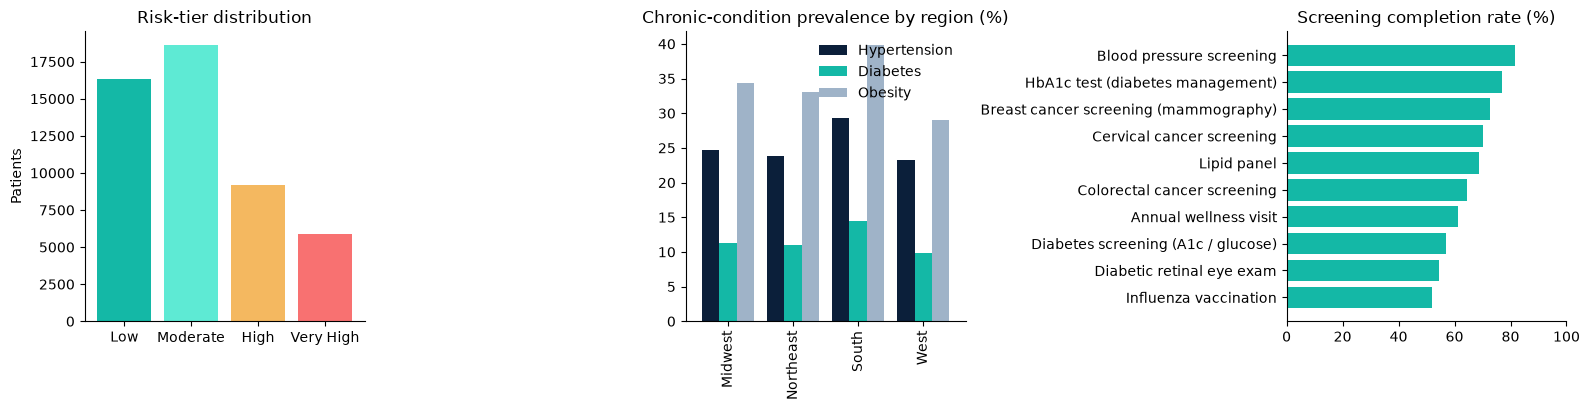

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
NAVY, TEAL, MUTED = "#0B1F3A", "#14B8A6", "#9FB3C8"

tier_counts = pl.risk_tier.value_counts().reindex(["Low", "Moderate", "High", "Very High"])
axes[0].bar(tier_counts.index, tier_counts.values, color=[TEAL, "#5EEAD4", "#F4B860", "#F87171"])
axes[0].set_title("Risk-tier distribution"); axes[0].set_ylabel("Patients")

prev_region = pl.groupby("region")[["has_hypertension", "has_diabetes", "has_obesity"]].mean().mul(100)
prev_region.plot(kind="bar", ax=axes[1], color=[NAVY, TEAL, MUTED], width=0.8)
axes[1].set_title("Chronic-condition prevalence by region (%)"); axes[1].legend(["Hypertension", "Diabetes", "Obesity"], frameon=False); axes[1].set_xlabel("")

sr = s.groupby("screening_name").is_completed.mean().mul(100).sort_values()
axes[2].barh(sr.index, sr.values, color=TEAL); axes[2].set_title("Screening completion rate (%)"); axes[2].set_xlim(0, 100)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Build the star schema

```
                       dim_date
                          │
 dim_geography ── dim_patient ──┬── fact_screening ──── dim_screening
                                ├── fact_condition ──── dim_condition
                                ├── fact_wearable_monthly
                                ├── fact_engagement_event ── dim_event_type
                                └── fact_patient_risk_snapshot
```

* Every fact carries integer surrogate keys (`*_key`) only; business identifiers stay on the dimension.
* `dim_date` is a full calendar (1980-01-01 → 2036-12-31, so historical onset dates and future due dates both resolve) so Power BI time intelligence works.
* `dim_patient` is a Type-1 dimension at the snapshot date and carries the analytic attributes used
  as slicers (age band, region key, risk tier, engagement segment).

In [13]:
# ---- dim_date ----
dates = pd.date_range("1980-01-01", "2036-12-31", freq="D")
dim_date = pd.DataFrame({
    "date_key": dates.strftime("%Y%m%d").astype(int),
    "date": dates.strftime("%Y-%m-%d"),
    "year": dates.year, "quarter": dates.quarter, "quarter_label": "Q" + dates.quarter.astype(str) + " " + dates.year.astype(str),
    "month": dates.month, "month_name": dates.strftime("%b"), "year_month": dates.strftime("%Y-%m"),
    "month_start_date": dates.to_period("M").start_time.strftime("%Y-%m-%d"),
    "week_of_year": dates.isocalendar().week.values, "day_of_week": dates.dayofweek + 1, "day_name": dates.strftime("%a"),
    "is_weekend": (dates.dayofweek >= 5).astype(int),
    "is_reporting_period": ((dates >= PERIOD_START) & (dates <= SNAPSHOT)).astype(int),
})
date_key = lambda ser: pd.to_datetime(ser).dt.strftime("%Y%m%d").astype("Int64")

# ---- dim_geography ----
dim_geography = (pl[["region", "state", "urbanicity"]].drop_duplicates().sort_values(["region", "state", "urbanicity"]).reset_index(drop=True))
dim_geography.insert(0, "geo_key", range(1, len(dim_geography) + 1))
STATE_FULL = {v: k for k, v in STATE_NAMES.items()}
dim_geography["state_name"] = dim_geography.state.map(STATE_FULL)
dim_geography["country"] = "United States"

# ---- dim_condition ----
dim_condition = pd.DataFrame([
    (1, "diabetes", "44054006", "Type 2 diabetes mellitus", "Cardiometabolic", 1, "HbA1c < 8.0 %"),
    (2, "hypertension", "59621000", "Essential hypertension", "Cardiovascular", 1, "BP < 140/90 mmHg"),
    (3, "obesity", "414916001", "Obesity (BMI 30+)", "Cardiometabolic", 1, "N/A"),
    (4, "hyperlipidemia", "55822004", "Hyperlipidemia", "Cardiovascular", 0, "LDL-C < 130 mg/dL"),
    (5, "asthma", "195967001", "Asthma", "Respiratory", 0, "N/A"),
], columns=["condition_key", "condition_id", "snomed_code", "condition_name", "condition_category", "is_focus_condition", "control_target"])

# ---- dim_screening ----
SCREEN_META = {
    "AWV": ("Annual wellness visit", "Wellness", "CMS", "Any", 18, 120),
    "BP": ("Blood pressure screening", "Cardiovascular", "USPSTF Grade A", "Any", 18, 120),
    "FLU": ("Influenza vaccination", "Immunisation", "ACIP", "Any", 18, 120),
    "LIPID": ("Lipid panel", "Cardiovascular", "USPSTF Grade B", "Any", 40, 75),
    "A1C_SCREEN": ("Diabetes screening (A1c / glucose)", "Cardiometabolic", "USPSTF Grade B", "Any", 35, 70),
    "CRC": ("Colorectal cancer screening", "Cancer", "USPSTF Grade A/B", "Any", 45, 75),
    "MAMMO": ("Breast cancer screening (mammography)", "Cancer", "USPSTF Grade B", "F", 40, 74),
    "CERVICAL": ("Cervical cancer screening", "Cancer", "USPSTF Grade A", "F", 21, 65),
    "A1C_DM": ("HbA1c test (diabetes management)", "Chronic disease management", "HEDIS HBD", "Any", 18, 120),
    "EYE_DM": ("Diabetic retinal eye exam", "Chronic disease management", "HEDIS EED", "Any", 18, 120),
}
dim_screening = (s[["screening_code", "recommended_interval_months"]].drop_duplicates().sort_values("screening_code").reset_index(drop=True))
dim_screening.insert(0, "screening_key", range(1, len(dim_screening) + 1))
dim_screening["screening_name"] = dim_screening.screening_code.map(lambda k: SCREEN_META[k][0])
dim_screening["screening_category"] = dim_screening.screening_code.map(lambda k: SCREEN_META[k][1])
dim_screening["guideline_source"] = dim_screening.screening_code.map(lambda k: SCREEN_META[k][2])
dim_screening["eligible_sex"] = dim_screening.screening_code.map(lambda k: SCREEN_META[k][3])
dim_screening["min_age"] = dim_screening.screening_code.map(lambda k: SCREEN_META[k][4])
dim_screening["max_age"] = dim_screening.screening_code.map(lambda k: SCREEN_META[k][5])

# ---- dim_event_type ----
dim_event_type = e[["event_type", "event_category"]].drop_duplicates().sort_values(["event_category", "event_type"]).reset_index(drop=True)
dim_event_type.insert(0, "event_type_key", range(1, len(dim_event_type) + 1))
dim_event_type["event_label"] = dim_event_type.event_type.str.replace("_", " ").str.capitalize()
dim_event_type["is_meaningful_action"] = dim_event_type.event_type.isin(
    ["appointment_booking", "medication_reminder_acknowledged", "screening_reminder_viewed", "message_to_care_team"]).astype(int)

# ---- dim_patient ----
dim_patient = pl.merge(dim_geography[["geo_key", "region", "state", "urbanicity"]], on=["region", "state", "urbanicity"], how="left")
dim_patient.insert(0, "patient_key", range(1, len(dim_patient) + 1))
dim_patient["app_enrollment_date_key"] = date_key(dim_patient.app_enrollment_date)
dim_patient["birth_date"] = dim_patient.birth_date.dt.strftime("%Y-%m-%d")
dim_patient["app_enrollment_date"] = dim_patient.app_enrollment_date.dt.strftime("%Y-%m-%d")
dim_patient["last_event_date"] = pd.to_datetime(dim_patient.last_event_date).dt.strftime("%Y-%m-%d")
dim_patient["multimorbid"] = (dim_patient.chronic_condition_count >= 2).astype(int)
dim_patient["any_focus_condition"] = ((dim_patient.has_diabetes + dim_patient.has_hypertension + dim_patient.has_obesity) > 0).astype(int)
dim_patient["sex_label"] = dim_patient.sex.map({"F": "Female", "M": "Male"})
dim_patient["adi_band"] = pd.cut(dim_patient.adi_decile, bins=[0, 3, 7, 10], labels=["Low deprivation (1–3)", "Moderate (4–7)", "High deprivation (8–10)"]).astype(str)
dim_patient["age_band_order"] = dim_patient.age_band.map({l: i + 1 for i, l in enumerate(AGE_LABELS)})
dim_patient = dim_patient[[
    "patient_key", "patient_id", "geo_key", "birth_date", "age", "age_band", "age_band_order", "sex", "sex_label", "race_ethnicity",
    "insurance_type", "smoking_status", "adi_decile", "adi_band", "has_primary_care_provider", "height_cm", "weight_kg", "bmi",
    "bmi_category", "bmi_imputed", "has_diabetes", "has_hypertension", "has_obesity", "has_hyperlipidemia", "has_asthma",
    "any_focus_condition", "chronic_condition_count", "multimorbid", "uncontrolled_condition_count", "eligible_screenings",
    "completed_screenings", "open_care_gaps", "app_enrolled", "app_enrollment_date", "app_enrollment_date_key", "engagement_segment",
    "is_engaged_user", "wearable_user", "wearable_device", "avg_daily_steps_12m", "avg_sleep_hours_12m", "avg_resting_hr_12m",
    "risk_score", "risk_tier", "risk_tier_order",
]]
for col in ["avg_daily_steps_12m", "avg_sleep_hours_12m", "avg_resting_hr_12m"]:
    dim_patient[col] = dim_patient[col].round(1)
dim_patient["wearable_device"] = dim_patient.wearable_device.fillna("None")

pk = dim_patient.set_index("patient_id").patient_key
print({n: len(d) for n, d in {"dim_date": dim_date, "dim_geography": dim_geography, "dim_condition": dim_condition,
                             "dim_screening": dim_screening, "dim_event_type": dim_event_type, "dim_patient": dim_patient}.items()})
dim_patient.head(3)

{'dim_date': 20820, 'dim_geography': 60, 'dim_condition': 5, 'dim_screening': 10, 'dim_event_type': 7, 'dim_patient': 50000}


,patient_key,patient_id,geo_key,birth_date,age,age_band,age_band_order,sex,sex_label,race_ethnicity,insurance_type,smoking_status,adi_decile,adi_band,has_primary_care_provider,height_cm,weight_kg,bmi,bmi_category,bmi_imputed,has_diabetes,has_hypertension,has_obesity,has_hyperlipidemia,has_asthma,any_focus_condition,chronic_condition_count,multimorbid,uncontrolled_condition_count,eligible_screenings,completed_screenings,open_care_gaps,app_enrolled,app_enrollment_date,app_enrollment_date_key,engagement_segment,is_engaged_user,wearable_user,wearable_device,avg_daily_steps_12m,avg_sleep_hours_12m,avg_resting_hr_12m,risk_score,risk_tier,risk_tier_order
0,1,P0016478,53,1992-02-11,33,30–39,2,F,Female,Black or African American,Commercial,Never,5,Moderate (4–7),0,174.4,63.0,20.7,Normal,0,0,0,0,0,0,0,0,0,0,4,2,2,1,2024-09-20,20240920,Dormant,0,1,Apple Watch,9282.3,7.8,60.6,3,Low,1
1,2,P0009003,51,1998-09-18,27,18–29,1,F,Female,White,Commercial,Never,5,Moderate (4–7),1,169.4,76.0,26.5,Overweight,0,0,0,0,0,0,0,0,0,0,4,1,3,0,NaN,<NA>,Not enrolled,0,1,Garmin,7689.8,5.8,66.7,3,Low,1
2,3,P0022486,55,1990-04-22,35,30–39,2,F,Female,Other / Multiracial,Commercial,Never,7,Moderate (4–7),1,148.4,36.3,16.5,Underweight,0,0,0,0,0,0,0,0,0,0,5,2,3,1,2024-11-18,20241118,Occasional,0,1,Apple Watch,12376.1,8.3,67.7,3,Low,1


In [14]:
# ---- fact_condition ----
ck = dim_condition.set_index("condition_id").condition_key
fact_condition = pd.DataFrame({
    "condition_record_id": c.condition_record_id.values,
    "patient_key": c.patient_id.map(pk).values,
    "condition_key": c.condition_key.map(ck).values,
    "onset_date_key": date_key(c.onset_date).values,
    "snapshot_date_key": int(SNAPSHOT.strftime("%Y%m%d")),
    "measure_name": c.measure_name.values, "measure_value": c.measure_value.values,
    "secondary_measure_name": c.secondary_measure_name.values, "secondary_measure_value": c.secondary_measure_value.values,
    "control_status": c.control_status.values, "is_controlled": c.is_controlled.values, "is_uncontrolled": c.is_uncontrolled.values,
    "on_medication": c.on_medication.values,
    "years_since_onset": ((SNAPSHOT - c.onset_date).dt.days / 365.25).round(1).values,
})

# ---- fact_screening ----
sk = dim_screening.set_index("screening_code").screening_key
fact_screening = pd.DataFrame({
    "screening_record_id": s.screening_record_id.values,
    "patient_key": s.patient_id.map(pk).values,
    "screening_key": s.screening_code.map(sk).values,
    "snapshot_date_key": int(SNAPSHOT.strftime("%Y%m%d")),
    "last_completed_date_key": date_key(s.last_completed_date).values,
    "next_due_date_key": date_key(s.next_due_date).values,
    "is_eligible": s.is_eligible.values, "is_completed": s.is_completed.values, "is_care_gap": s.is_care_gap.values,
    "screening_status": s.screening_status.values, "days_since_last": s.days_since_last.values, "days_overdue": s.days_overdue.values,
    "reminder_sent": s.reminder_sent.values, "completed_flag_raw": s.completed_flag_raw.values,
})

# ---- fact_wearable_monthly ----
fact_wearable_monthly = pd.DataFrame({
    "wearable_record_id": w.wearable_record_id.values,
    "patient_key": w.patient_id.map(pk).values,
    "month_date_key": date_key(w.month_start).values,
    "year_month": w.month.values, "device_type": w.device_type.values,
    "avg_daily_steps": w.avg_daily_steps.values, "avg_sleep_hours": w.avg_sleep_hours.values, "avg_resting_hr": w.avg_resting_hr.values,
    "active_days": w.active_days.values, "days_with_10k_steps": w.days_with_10k_steps.values, "meets_10k_steps": w.meets_10k_steps.values,
    "activity_band": w.activity_band.values, "sleep_band": w.sleep_band.values,
})

# ---- fact_engagement_event ----
ek = dim_event_type.set_index("event_type").event_type_key
fact_engagement_event = pd.DataFrame({
    "event_id": e.event_id.values,
    "patient_key": e.patient_id.map(pk).values,
    "event_type_key": e.event_type.map(ek).values,
    "date_key": date_key(e.event_date).values,
    "event_timestamp": e.event_timestamp.dt.strftime("%Y-%m-%d %H:%M:%S").values,
    "hour_of_day": e.event_timestamp.dt.hour.values,
    "channel": e.channel.values, "session_minutes": e.session_minutes.values,
    "is_login": e.is_login.values, "is_booking": e.is_booking.values, "is_med_reminder_ack": e.is_med_reminder_ack.values,
    "event_count": 1,
})

# ---- fact_patient_risk_snapshot ----
fact_patient_risk_snapshot = dim_patient[[
    "patient_key", "risk_score", "risk_tier", "chronic_condition_count", "uncontrolled_condition_count", "open_care_gaps",
    "eligible_screenings", "completed_screenings", "avg_daily_steps_12m", "avg_sleep_hours_12m", "avg_resting_hr_12m", "is_engaged_user",
]].copy()
fact_patient_risk_snapshot.insert(1, "snapshot_date_key", int(SNAPSHOT.strftime("%Y%m%d")))
fact_patient_risk_snapshot["age_points"] = np.select([pl.age >= 75, pl.age >= 65, pl.age >= 50], [3, 2, 1], default=0)
fact_patient_risk_snapshot["chronic_points"] = 2 * pl.chronic_condition_count
fact_patient_risk_snapshot["obesity_points"] = np.select([pl.bmi >= 40, pl.bmi >= 35, pl.bmi >= 30], [3, 2, 1], default=0)
fact_patient_risk_snapshot["control_points"] = 2 * pl.uncontrolled_condition_count
fact_patient_risk_snapshot["smoking_points"] = pl.smoking_status.map({"Current": 2, "Former": 1, "Never": 0}).fillna(0).astype(int)
fact_patient_risk_snapshot["inactivity_points"] = np.where(pl.avg_daily_steps_12m < 5000, 2, 0)
fact_patient_risk_snapshot["care_gap_points"] = pl.open_care_gaps.clip(upper=4)
fact_patient_risk_snapshot["social_points"] = np.where(pl.adi_decile >= 8, 1, 0)
fact_patient_risk_snapshot["access_points"] = np.where(pl.has_primary_care_provider == 0, 1, 0)
fact_patient_risk_snapshot["screening_completion_rate"] = (fact_patient_risk_snapshot.completed_screenings / fact_patient_risk_snapshot.eligible_screenings.replace(0, np.nan)).round(3)

facts = {"fact_condition": fact_condition, "fact_screening": fact_screening, "fact_wearable_monthly": fact_wearable_monthly,
         "fact_engagement_event": fact_engagement_event, "fact_patient_risk_snapshot": fact_patient_risk_snapshot}
dims = {"dim_date": dim_date, "dim_patient": dim_patient, "dim_geography": dim_geography, "dim_condition": dim_condition,
        "dim_screening": dim_screening, "dim_event_type": dim_event_type}
print({n: f"{len(d):,}" for n, d in facts.items()})

{'fact_condition': '52,746', 'fact_screening': '294,717', 'fact_wearable_monthly': '307,534', 'fact_engagement_event': '295,432', 'fact_patient_risk_snapshot': '50,000'}


### 5.1 Referential-integrity checks

Every foreign key on every fact must resolve to exactly one dimension row, and the patient
dimension must be unique on both its surrogate and its natural key.

In [15]:
checks = []
def check(name, ok): checks.append((name, "PASS" if ok else "FAIL")); assert ok, name

check("dim_patient.patient_key unique", dim_patient.patient_key.is_unique)
check("dim_patient.patient_id unique", dim_patient.patient_id.is_unique)
check("dim_patient.geo_key → dim_geography", dim_patient.geo_key.isin(dim_geography.geo_key).all())
check("dim_date.date_key unique", dim_date.date_key.is_unique)
for name, f in facts.items():
    check(f"{name}.patient_key → dim_patient", f.patient_key.isin(dim_patient.patient_key).all())
    for col in [c_ for c_ in f.columns if c_.endswith("date_key")]:
        vals = f[col].dropna().astype(int)
        check(f"{name}.{col} → dim_date", vals.isin(dim_date.date_key).all())
check("fact_condition.condition_key → dim_condition", fact_condition.condition_key.isin(dim_condition.condition_key).all())
check("fact_screening.screening_key → dim_screening", fact_screening.screening_key.isin(dim_screening.screening_key).all())
check("fact_engagement_event.event_type_key → dim_event_type", fact_engagement_event.event_type_key.isin(dim_event_type.event_type_key).all())
check("fact_engagement_event.event_id unique", fact_engagement_event.event_id.is_unique)
check("fact_patient_risk_snapshot one row per patient", fact_patient_risk_snapshot.patient_key.is_unique)
pd.DataFrame(checks, columns=["check", "result"])

,check,result
0,dim_patient.patient_key unique,PASS
1,dim_patient.patient_id unique,PASS
2,dim_patient.geo_key → dim_geography,PASS
3,dim_date.date_key unique,PASS
4,fact_condition.patient_key → dim_patient,PASS
5,fact_condition.onset_date_key → dim_date,PASS
6,fact_condition.snapshot_date_key → dim_date,PASS
7,fact_screening.patient_key → dim_patient,PASS
8,fact_screening.snapshot_date_key → dim_date,PASS
9,fact_screening.last_completed_date_key → dim_date,PASS


## 6. Export

* Star-schema CSVs → `data/star_schema/` (UTF-8, ISO dates, integer keys) — load these in Power BI.
* `docs/summary_stats.json` — headline KPIs reused by the README and the slide deck.
* `docs/data_dictionary.md` — auto-generated column inventory of the star schema.

In [16]:
for name, df in {**dims, **facts}.items():
    df.to_csv(OUT / f"{name}.csv", index=False)
    print(f"  {name:<28} {len(df):>9,} rows  {df.shape[1]:>3} cols  {((OUT / f'{name}.csv').stat().st_size / 1e6):6.1f} MB")

  dim_date                        20,820 rows   14 cols     1.5 MB


  dim_patient                     50,000 rows   45 cols    10.8 MB
  dim_geography                       60 rows    6 cols     0.0 MB
  dim_condition                        5 rows    7 cols     0.0 MB
  dim_screening                       10 rows    9 cols     0.0 MB
  dim_event_type                       7 rows    5 cols     0.0 MB
  fact_condition                  52,746 rows   14 cols     3.8 MB


  fact_screening                 294,717 rows   14 cols    19.9 MB


  fact_wearable_monthly          307,534 rows   13 cols    33.7 MB


  fact_engagement_event          295,432 rows   12 cols    19.8 MB


  fact_patient_risk_snapshot      50,000 rows   23 cols     3.5 MB


In [17]:
n = len(dim_patient)
enrolled = dim_patient[dim_patient.app_enrolled == 1]
focus = dim_patient[dim_patient.any_focus_condition == 1]
elig_dm_eye = fact_screening.merge(dim_screening[["screening_key", "screening_code"]], on="screening_key")

def pct(x): return round(float(x) * 100, 1)

stats = {
    "snapshot_date": SNAPSHOT.strftime("%Y-%m-%d"),
    "period": f"{PERIOD_START.strftime('%b %Y')} – {SNAPSHOT.strftime('%b %Y')}",
    "patients": int(n),
    "raw_rows_in": {k: int(len(v)) for k, v in raw.items()},
    "rows_removed": {"patients": int(len(raw['patients']) - n), "conditions": int(len(raw['conditions']) - len(c)),
                     "wearable_monthly": int(len(raw['wearable_monthly']) - len(w)), "engagement_events": int(len(raw['engagement_events']) - len(e))},
    "star_schema_rows": {k: int(len(v)) for k, v in {**dims, **facts}.items()},
    "demographics": {
        "median_age": float(dim_patient.age.median()), "pct_female": pct(dim_patient.sex.eq("F").mean()),
        "pct_65_plus": pct((dim_patient.age >= 65).mean()),
        "region_share": {k: pct(v) for k, v in dim_patient.region.value_counts(normalize=True).items()} if "region" in dim_patient else
                        {k: pct(v) for k, v in dim_patient.merge(dim_geography[["geo_key", "region"]], on="geo_key").region.value_counts(normalize=True).items()},
        "insurance_share": {k: pct(v) for k, v in dim_patient.insurance_type.value_counts(normalize=True).items()},
    },
    "prevalence_pct": {
        "diabetes": pct(dim_patient.has_diabetes.mean()), "hypertension": pct(dim_patient.has_hypertension.mean()),
        "obesity": pct(dim_patient.has_obesity.mean()), "hyperlipidemia": pct(dim_patient.has_hyperlipidemia.mean()),
        "asthma": pct(dim_patient.has_asthma.mean()), "any_focus_condition": pct(dim_patient.any_focus_condition.mean()),
        "multimorbid": pct(dim_patient.multimorbid.mean()),
    },
    "prevalence_by_region_pct": (dim_patient.merge(dim_geography[["geo_key", "region"]], on="geo_key")
                                 .groupby("region")[["has_hypertension", "has_diabetes", "has_obesity"]].mean().mul(100).round(1)
                                 .rename(columns=lambda c_: c_.replace("has_", "")).to_dict(orient="index")),
    "prevalence_by_age_band_pct": (dim_patient.groupby("age_band")[["has_hypertension", "has_diabetes", "has_obesity"]].mean().mul(100).round(1)
                                   .rename(columns=lambda c_: c_.replace("has_", "")).to_dict(orient="index")),
    "control_pct": {
        "hypertension": pct(fact_condition[fact_condition.condition_key == 2].is_controlled.mean()),
        "diabetes": pct(fact_condition[fact_condition.condition_key == 1].is_controlled.mean()),
        "hyperlipidemia": pct(fact_condition[fact_condition.condition_key == 4].is_controlled.mean()),
    },
    "screening": {
        "overall_completion_pct": pct(fact_screening.is_completed.mean()),
        "open_care_gaps": int(fact_screening.is_care_gap.sum()),
        "patients_with_any_gap_pct": pct((dim_patient.open_care_gaps > 0).mean()),
        "by_screening_pct": elig_dm_eye.groupby("screening_code").is_completed.mean().mul(100).round(1).to_dict(),
        "by_region_pct": (fact_screening.merge(dim_patient[["patient_key", "geo_key"]], on="patient_key").merge(dim_geography[["geo_key", "region"]], on="geo_key")
                          .groupby("region").is_completed.mean().mul(100).round(1).to_dict()),
        "enrolled_vs_not_pct": (fact_screening.merge(dim_patient[["patient_key", "app_enrolled"]], on="patient_key")
                                .groupby("app_enrolled").is_completed.mean().mul(100).round(1).rename({0: "not_enrolled", 1: "enrolled"}).to_dict()),
        "engaged_vs_not_pct": (fact_screening.merge(dim_patient[["patient_key", "engagement_segment"]], on="patient_key")
                               .groupby("engagement_segment").is_completed.mean().mul(100).round(1).to_dict()),
    },
    "engagement": {
        "enrolled_pct": pct(dim_patient.app_enrolled.mean()),
        "engaged_active_pct_of_enrolled": pct(enrolled.is_engaged_user.mean()),
        "engagement_segments_pct_of_population": {k: pct(v) for k, v in dim_patient.engagement_segment.value_counts(normalize=True).items()},
        "events_total": int(len(fact_engagement_event)),
        "events_by_type": fact_engagement_event.merge(dim_event_type, on="event_type_key").event_type.value_counts().to_dict(),
        "events_by_channel_pct": {k: pct(v) for k, v in fact_engagement_event.channel.value_counts(normalize=True).items()},
        "monthly_active_users": (fact_engagement_event.assign(ym=fact_engagement_event.date_key.astype(str).str[:6])
                                 .groupby("ym").patient_key.nunique().to_dict()),
        "appointment_bookings": int(fact_engagement_event.is_booking.sum()),
        "med_reminder_ack_rate_pct": pct(fact_engagement_event.is_med_reminder_ack.sum() /
                                         max(1, (fact_engagement_event.merge(dim_event_type, on="event_type_key").event_type == "medication_reminder_sent").sum())),
    },
    "wearables": {
        "wearable_users_pct": pct(dim_patient.wearable_user.mean()),
        "median_daily_steps": float(fact_wearable_monthly.avg_daily_steps.median()),
        "median_sleep_hours": float(fact_wearable_monthly.avg_sleep_hours.median()),
        "median_resting_hr": float(fact_wearable_monthly.avg_resting_hr.median()),
        "pct_months_10k_steps": pct(fact_wearable_monthly.meets_10k_steps.mean()),
        "activity_band_pct": {k: pct(v) for k, v in fact_wearable_monthly.activity_band.value_counts(normalize=True).items()},
        "steps_by_risk_tier": dim_patient.groupby("risk_tier").avg_daily_steps_12m.mean().round(0).to_dict(),
        "steps_by_month": fact_wearable_monthly.groupby("year_month").avg_daily_steps.mean().round(0).to_dict(),
    },
    "risk": {
        "tier_distribution_pct": {k: pct(v) for k, v in dim_patient.risk_tier.value_counts(normalize=True).items()},
        "tier_counts": dim_patient.risk_tier.value_counts().to_dict(),
        "mean_score": round(float(dim_patient.risk_score.mean()), 2),
        "high_or_very_high_pct": pct(dim_patient.risk_tier.isin(["High", "Very High"]).mean()),
        "priority_outreach_cohort": int((dim_patient.risk_tier.isin(["High", "Very High"]) & (dim_patient.open_care_gaps >= 1) & (dim_patient.is_engaged_user == 0)).sum()),
        "rising_risk_patients": int(((dim_patient.risk_tier == "Moderate") & (dim_patient.uncontrolled_condition_count >= 1)).sum()),
        "high_risk_with_gaps": int((dim_patient.risk_tier.isin(["High", "Very High"]) & (dim_patient.open_care_gaps >= 1)).sum()),
        "care_gaps_by_tier": dim_patient.groupby("risk_tier").open_care_gaps.mean().round(2).to_dict(),
        "screening_rate_by_tier_pct": (fact_screening.merge(dim_patient[["patient_key", "risk_tier"]], on="patient_key")
                                        .groupby("risk_tier").is_completed.mean().mul(100).round(1).to_dict()),
        "engaged_pct_by_tier": dim_patient.groupby("risk_tier").is_engaged_user.mean().mul(100).round(1).to_dict(),
        "tier_by_region_pct": (dim_patient.merge(dim_geography[["geo_key", "region"]], on="geo_key")
                               .pivot_table(index="region", columns="risk_tier", values="patient_key", aggfunc="count")
                               .div(dim_patient.merge(dim_geography[["geo_key", "region"]], on="geo_key").region.value_counts(), axis=0)
                               .mul(100).round(1).to_dict(orient="index")),
    },
    "data_quality": {r["issue"]: {"before": int(r["rows_before"]), "after": int(r["rows_after"])} for _, r in scorecard.iterrows()},
}
(DOCS / "summary_stats.json").write_text(json.dumps(stats, indent=2, default=str))
print(json.dumps({k: stats[k] for k in ["patients", "prevalence_pct", "control_pct", "engagement", "risk"]}, indent=2, default=str)[:3000])

{
  "patients": 50000,
  "prevalence_pct": {
    "diabetes": 12.1,
    "hypertension": 25.9,
    "obesity": 34.9,
    "hyperlipidemia": 25.9,
    "asthma": 6.7,
    "any_focus_condition": 50.1,
    "multimorbid": 18.3
  },
  "control_pct": {
    "hypertension": 51.2,
    "diabetes": 63.2,
    "hyperlipidemia": 37.9
  },
  "engagement": {
    "enrolled_pct": 66.5,
    "engaged_active_pct_of_enrolled": 56.1,
    "engagement_segments_pct_of_population": {
      "Active": 37.3,
      "Not enrolled": 33.5,
      "Occasional": 19.0,
      "Dormant": 10.2
    },
    "events_total": 295432,
    "events_by_type": {
      "login": 153578,
      "medication_reminder_sent": 41586,
      "medication_reminder_acknowledged": 29368,
      "appointment_booking": 26515,
      "screening_reminder_viewed": 23610,
      "message_to_care_team": 11783,
      "wearable_sync": 8992
    },
    "events_by_channel_pct": {
      "iOS": 48.1,
      "Android": 37.8,
      "Web": 14.1
    },
    "monthly_active_users

In [18]:
# Auto-generated data dictionary for the star schema
DESCRIPTIONS = {
    "patient_key": "Surrogate key for the patient (integer).", "patient_id": "Natural patient identifier from the source system.",
    "geo_key": "FK → dim_geography.", "date_key": "FK → dim_date (yyyymmdd integer).", "condition_key": "FK → dim_condition.",
    "screening_key": "FK → dim_screening.", "event_type_key": "FK → dim_event_type.",
    "risk_score": "Additive rules-based risk score (see notebook §4).", "risk_tier": "Low / Moderate / High / Very High.",
    "is_completed": "1 if the screening is documented within the guideline interval as of the snapshot.",
    "is_care_gap": "1 if the patient is eligible but not up to date (Overdue or Never screened).",
    "control_status": "Controlled / Uncontrolled / N/A using guideline thresholds.",
    "engagement_segment": "Active (3+ active months) / Occasional / Dormant / Not enrolled.",
    "avg_daily_steps": "Mean daily step count for the device-month (nulled if implausible).",
}
lines = ["# Star-schema data dictionary", "", f"Generated by `notebooks/01_clean_and_build_star_schema.ipynb` on snapshot {SNAPSHOT.date()}.", ""]
for name, df in {**dims, **facts}.items():
    kind = "Dimension" if name.startswith("dim_") else "Fact"
    lines += [f"## `{name}` ({kind}, {len(df):,} rows)", "", "| Column | Type | Example | Notes |", "|---|---|---|---|"]
    for col in df.columns:
        ex = df[col].dropna().iloc[0] if df[col].notna().any() else ""
        lines.append(f"| `{col}` | {df[col].dtype} | {str(ex)[:32]} | {DESCRIPTIONS.get(col, '')} |")
    lines.append("")
(DOCS / "data_dictionary.md").write_text("\n".join(lines))
print(f"Data dictionary written: {DOCS / 'data_dictionary.md'} ({len(lines)} lines)")

Data dictionary written: /home/user/health-analytics/03-population-health-powerbi/docs/data_dictionary.md (221 lines)


## 7. What the model now supports

With the star schema in place the Power BI model can answer, with correct denominators, questions such as:

* **Prevalence** – share of the attributed population living with diabetes, hypertension or obesity, sliced by region,
  age band, insurance and deprivation.
* **Preventive care** – screening completion rate by guideline, region and risk tier; number of open care gaps and the
  patients behind them.
* **Digital engagement** – enrolment and active-use rates, monthly active users, appointment bookings and medication
  reminder acknowledgement.
* **Wearable-derived behaviour** – activity and sleep bands by cohort, and how they differ across risk tiers.
* **Risk stratification** – distribution of the population across four tiers, and how engagement and screening
  performance vary by tier.

See `powerbi/dashboard_spec.md` for the page-by-page dashboard design and `powerbi/measures.dax` for the measure library.